In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline


In [4]:
df=pd.read_csv('task for muda/KenyaConsump.csv')

In [9]:
df.head(30)

,year,Industry,Transport,Resident,Agric,com,NonEner,NonSpecific,total
0,2000,16414,37644,16300,3819,2269,2981,622,80049
1,2001,17965,37087,13372,3692,2187,2519,577,77399
2,2002,18465,38728,12244,3106,2055,2875,533,78006
3,2003,15508,34696,9006,2390,2098,1733,443,65874
4,2004,17050,38203,10802,2433,2445,1179,486,72598
5,2005,20307,39950,13278,1510,2797,1807,395,80044
6,2006,24380,44703,12419,1467,3322,2011,438,88740
7,2007,23060,45192,12414,2390,3633,2119,573,89381
8,2008,24115,46426,11626,1550,3721,2507,438,90383
9,2009,23245,57548,15890,1090,4411,2795,437,105416


In [6]:
# 1. Input Data from the image
years = np.array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013])
values = np.array([103172, 82723, 62820, 58192, 86005, 74644, 69132, 67281, 74602, 68501, 65303, 74560, 41950, 23857])


In [10]:
# Generate smooth x-axis values for plotting the curves
years_smooth = np.linspace(years.min(), years.max(), 300)


In [11]:
# 2. Polynomial Least-Squares Regression (e.g., Degree 3)
# ---------------------------------------------------------
# You can change the degree (3) to 2, 4, etc., depending on the desired fit
poly_degree = 3
coefficients = np.polyfit(years, values, poly_degree)
poly_model = np.poly1d(coefficients)
values_poly = poly_model(years_smooth)

print(f"--- Polynomial Regression Coefficients (Degree {poly_degree}) ---")
print(poly_model)


--- Polynomial Regression Coefficients (Degree 3) ---
      3             2
-198 x + 1.192e+06 x - 2.39e+09 x + 1.599e+12


In [12]:
# 3. Cubic Spline Interpolation
# ---------------------------------------------------------
# bc_type='not-a-knot' is standard, forcing a smooth curve through all exact points
cs = CubicSpline(years, values, bc_type="not-a-knot")
values_spline = cs(years_smooth)


In [13]:
# 4. Plotting the Results
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

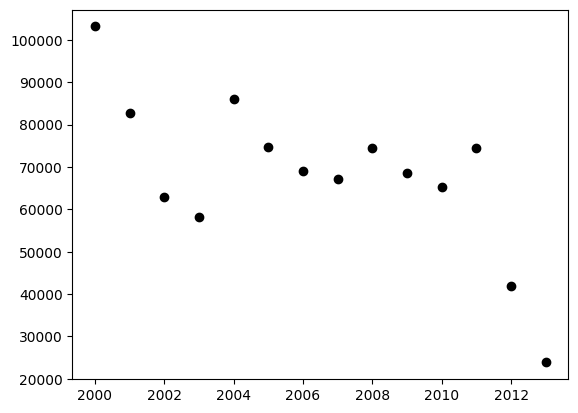

In [14]:
# Plot actual data points
plt.scatter(years, values, color="black", zorder=5, label="Original Data (TJ)")


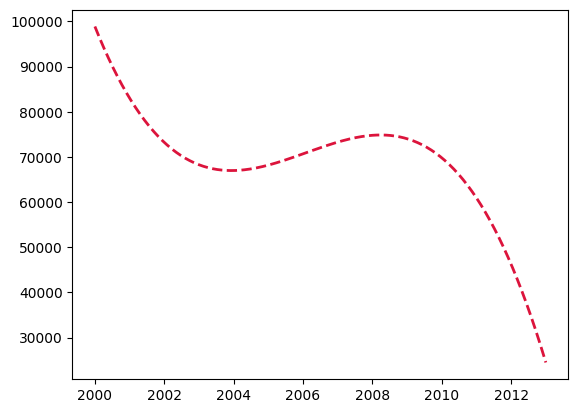

In [15]:
# Plot Polynomial Regression
plt.plot(
    years_smooth,
    values_poly,
    label=f"Polynomial Regression (Degree {poly_degree})",
    color="crimson",
    linestyle="--",
    linewidth=2,
)

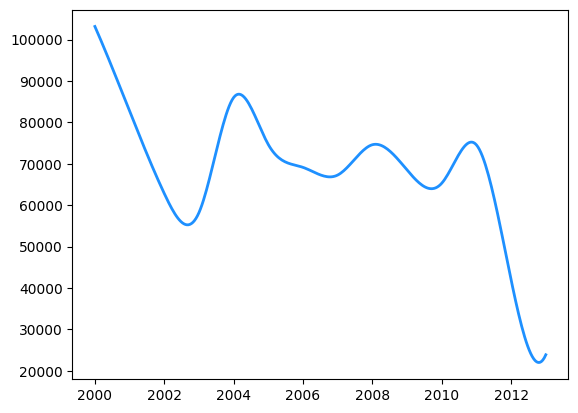

In [16]:
# Plot Cubic Spline
plt.plot(years_smooth, values_spline, label="Cubic Spline Interpolation", color="dodgerblue", linewidth=2)


C:\Users\USER\AppData\Local\Temp\ipykernel_11356\897683584.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=11)


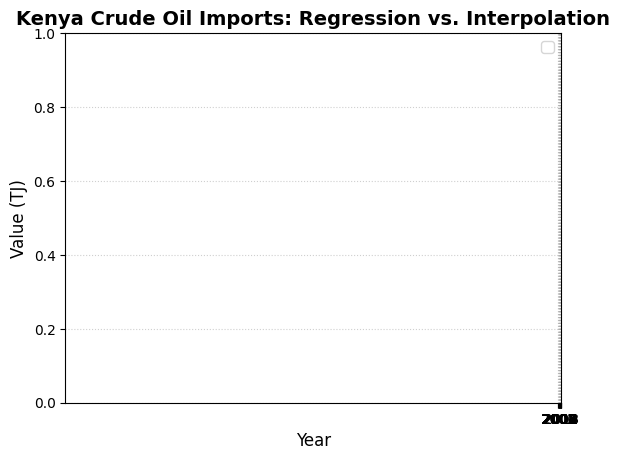

In [17]:
# Customizing the graph
plt.title("Kenya Crude Oil Imports: Regression vs. Interpolation", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Value (TJ)", fontsize=12)
plt.xticks(years) # Show every year on x-axis
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)


In [18]:
# Display the plot
plt.tight_layout()
plt.show()



<Figure size 640x480 with 0 Axes>